# Gaussian Variational Bayes

## Creación del dataset

Se modela el comportamiento de puntualidad de estudiantes que asisten a una clase universitaria. Estos comportamientos pueden ser capturados mediante modelos de mezclas. Por lo que, modelamos el tiempo de llegada como una variable aleatoria que sigue una distribución de mezcla de gaussianas.

La mezcla de gaussianas verdadera que utilizamos para generar los datos consta de 4 componentes, cada uno reprsentando un patrón de comportamiento distinto ( distinto peso, media y varianza). Donde:

* w = 0.1 , μ = -4 , $σ^2$ = 1 : Representa a los estudiantes muy puntuales que llegan antes de tiempo.

* w = 0.4 , μ = 0 , $σ^2$ = 1.96 : Captura el comportamiento mayoritario de estudiantes que tienden a llegar exactamente a horario.

* w = 0.2 , μ = 4 , $σ^2$ = 1.44 : Modela los estudiantes  que llegan unos minutos tarde.

* w = 0.3 , μ = 5 , $σ^2$ = 1 : Representa los estudiantes imputuales.

La densidad de probabilidad de esta mezcla se expresa matematicamente como:
$$p(x)=\sum_{k=1}^4 \pi_k \mathcal{N}(x|\mu_k,\sigma^2_k)$$
donde $\pi_k$ son los pesos de mezcla que satisfacen:
$$\sum_k \pi_k = 1\,,\, \pi_k \geq 0$$

Para cada una de las 100 observaciones, primero seleccionamos aleatoriamente una componente k según la distribución categorica definida por los pesos $\pi_k$ y luego generamos una muestra de la distribución normal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, digamma, softmax

In [2]:
# Fijamos semilla para reproducibilidad
np.random.seed(10)

# Parámetros de la mezcla de gaussianas verdadera (4 componentes)
pesos = np.array([0.1, 0.4, 0.2, 0.3])  # Pesos de cada componente
medias = np.array([-4, 0, 4, 5])  # Medias de cada componente
varianzas = np.array([1, 1.96, 1.44, 1])  # Varianzas de cada componente
n = 100  # Número total de muestras a generar

# Generamos las muestras
muestras = []  # Lista para almacenar las muestras
for _ in range(n):  # Iteramos para generar cada muestra
    # Seleccionamos aleatoriamente un componente según los pesos
    comp = np.random.choice(len(pesos), p=pesos)
    # Generamos una muestra de la gaussiana correspondiente
    sample = np.random.normal(medias[comp], np.sqrt(varianzas[comp]))
    muestras.append(sample)  # Agregamos la muestra a la lista

X = np.array(muestras).reshape(-1, 1)  # Convertimos a array de numpy con shape (100, 1)

# Función para calcular la densidad de una mezcla de gaussianas
def densidad_mezclas(x, pesos, medias, varianzas):
    densidad = np.zeros_like(x)  # Inicializamos el array de densidad en cero
    for w, mu, var in zip(pesos, medias, varianzas):  # Para cada componente
        # Sumamos la contribución de cada gaussiana ponderada por su peso
        densidad += w * (1 / np.sqrt(2 * np.pi * var)) * np.exp(-0.5 * (x - mu)**2 / var)
    return densidad  # Retornamos la densidad total

## K-means

K-means es un método de clustering no probabilistico que busca particionar las observaciones en K grupos minimizando la función:

$$J = \sum_{k=1}^K \sum_{x_i \in C_k}||x_i - \mu_k||^2$$
donde $C_k$ representa el conjunto de puntos asignados al cluster k y $\mu_k$ es el centroide del cluster.

El algoritmo procede alterando entre dos pasos, primero el *E-step* donde cada observación se asigna al cluster cuyo centroide está más cercano en términos de distancia euclidiana:
$$z_i = \arg\min_k ||x_i -\mu_k||^2$$

 Luego en el *M-step* cada centroide se actualiza como la media aritmetica de todas las observaciones asignadas a su cluster:

 $$\mu_k = \frac{1}{|C_k|}\sum_{x_i\in C_k}x_i$$

 Este proceso se repite hasta que el algoritmo converge o si alcanza un número máximo de iteraciones.
Una vez que K-means converge, se pueden utilizar los resultados para construir un modelo de mezclas de gaussianas inicial. Los centroides obtenidos se utilizan como estimaciones de las medias $\hat{\mu}_k$, los pesos de mezcla se estiman como la proporcion de observaciones asignadas a cada cluster $\hat{\pi}_k = \frac{|C_k|}{N}$, donde N es el número total de observaciones y las varianzas se estiman mediante la varianza muestral : $\hat{\sigma}_k^2 = \frac{1}{|C_k|-1}\sum_{x_i\in C_k}(x_i - \mu_k)^2$.

In [3]:
class KMeans:
    def __init__(self, n_clusters=6, max_iter=100, tol=1e-4):

        self.n_clusters = n_clusters  # Guardamos el número de clusters
        self.max_iter = max_iter  # Guardamos el máximo de iteraciones
        self.tol = tol  # Guardamos la tolerancia
        self.centroids = None  # Inicialmente no tenemos centroides
        self.labels_ = None  # Inicialmente no tenemos etiquetas

    def fit(self, X):
        n_samples = X.shape[0]  # Número de muestras

        # Inicializamos centroides aleatoriamente seleccionando K muestras
        idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[idx].copy()  # Copiamos las muestras seleccionadas

        # Iteramos hasta convergencia o máximo de iteraciones
        for iteration in range(self.max_iter):
            # E-step: Asignar cada muestra al centroide más cercano
            distances = np.zeros((n_samples, self.n_clusters))  # Matriz de distancias
            for k in range(self.n_clusters):  # Para cada cluster
                # Calculamos la distancia euclidiana al cuadrado
                distances[:, k] = np.sum((X - self.centroids[k])**2, axis=1)
            self.labels_ = np.argmin(distances, axis=1)  # Asignamos al cluster más cercano

            # M-step: Actualizar centroides como la media de cada cluster
            new_centroids = np.zeros_like(self.centroids)  # Nuevos centroides
            for k in range(self.n_clusters):  # Para cada cluster
                mask = self.labels_ == k  # Máscara de muestras en el cluster k
                if np.sum(mask) > 0:  # Si hay muestras en el cluster
                    new_centroids[k] = np.mean(X[mask], axis=0)  # Calculamos la media
                else:  # Si no hay muestras
                    new_centroids[k] = self.centroids[k]  # Mantenemos el centroide

            # Verificamos convergencia
            shift = np.sum(np.abs(new_centroids - self.centroids))  # Cambio total
            self.centroids = new_centroids  # Actualizamos centroides

            if shift < self.tol:  # Si el cambio es menor que la tolerancia
                break  # Convergimos, salimos del loop

        return self  # Retornamos la instancia

    def predict(self, X):
        n_samples = X.shape[0]  # Número de muestras
        distances = np.zeros((n_samples, self.n_clusters))  # Matriz de distancias
        for k in range(self.n_clusters):  # Para cada cluster
            # Calculamos distancia al centroide k
            distances[:, k] = np.sum((X - self.centroids[k])**2, axis=1)
        return np.argmin(distances, axis=1)  # Retornamos el cluster más cercano


### Gráfico K-Means



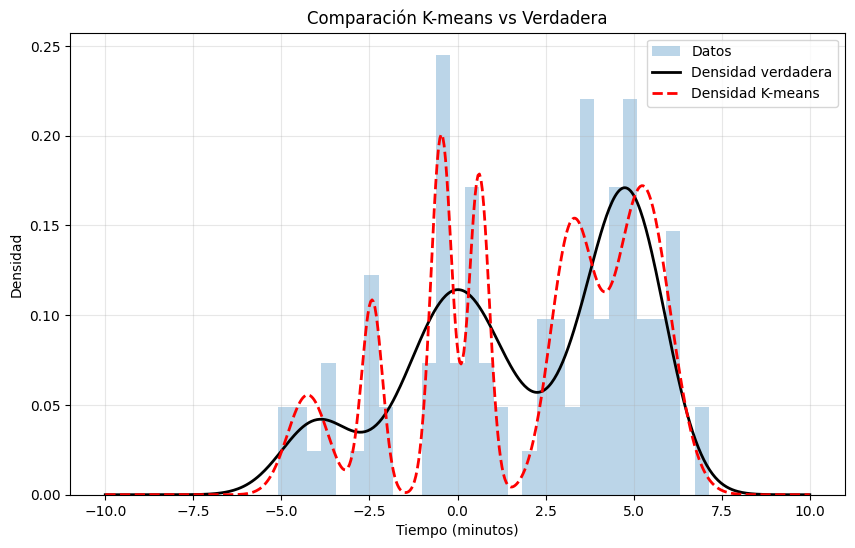

In [4]:
# Entrenamos K-means con 6 clusters (aunque sabemos que hay 4 verdaderos)
kmeans = KMeans(n_clusters=6, max_iter=100, tol=1e-4)
kmeans.fit(X)  # Ajustamos el modelo a los datos

# Estimamos parámetros de la mezcla de gaussianas con los resultados de K-means
kmeans_means = kmeans.centroids.flatten()  # Medias = centroides
kmeans_weights = np.zeros(6)  # Pesos = proporción de muestras en cada cluster
kmeans_variances = np.zeros(6)  # Varianzas = varianza intra-clase

for k in range(6):  # Para cada cluster
    mask = kmeans.labels_ == k  # Máscara de muestras en cluster k
    kmeans_weights[k] = np.mean(mask)  # Proporción de muestras
    if np.sum(mask) > 1:  # Si hay más de una muestra
        # Varianza intra-clase
        kmeans_variances[k] = np.var(X[mask], ddof=1)
    else:  # Si hay una o ninguna muestra
        kmeans_variances[k] = 1.0  # Varianza por defecto

# Normalizamos los pesos para que sumen 1
kmeans_weights = kmeans_weights / np.sum(kmeans_weights)

# Graficamos la densidad estimada por K-means vs la verdadera
x_plot = np.linspace(-10, 10, 500)  # Puntos para graficar
true_density = densidad_mezclas(x_plot, pesos, medias, varianzas)
kmeans_density = densidad_mezclas(x_plot, kmeans_weights, kmeans_means, kmeans_variances)

plt.figure(figsize=(10, 6))  # Creamos figura
plt.hist(X, bins=30, density=True, alpha=0.3, label='Datos')  # Histograma de datos
plt.plot(x_plot, true_density, 'k-', linewidth=2, label='Densidad verdadera')
plt.plot(x_plot, kmeans_density, 'r--', linewidth=2, label='Densidad K-means')
plt.xlabel('Tiempo (minutos)')  # Etiqueta eje x
plt.ylabel('Densidad')  # Etiqueta eje y
plt.title('Comparación K-means vs Verdadera')  # Título
plt.legend()  # Leyenda
plt.grid(True, alpha=0.3)  # Grilla
plt.show()  # Mostramos gráfico

El histograma normalizado de los datos observados proporciona una estimación no paramétrica de la densidad, mostrando la distribución empírica de los tiempos de llegada de los estudiantes. La curva negra sólida representa la densidad verdadera de la mezcla de gaussianas generativa. Esta densidad verdadera exhibe múltiples modas correspondientes a los cuatro patrones de comportamiento distintos: estudiantes muy puntuales (pico alrededor de -4 minutos), estudiantes que llegan a horario (pico cerca de 0), estudiantes relajados (pico alrededor de 4 minutos) y estudiantes consistentemente impuntuales (pico cerca de 5 minutos).
La curva roja discontinua representa la densidad estimada mediante el algoritmo K-means, que constituye nuestro primer intento de modelar la estructura de mezcla.  Se observa que la estimación de K-means captura parcialmente la estructura multimodal de los datos, identificando las principales concentraciones de masa probabilística, aunque con ciertas limitaciones debido a la naturaleza no probabilística del método.

El gráfico demuestra que K-means, aunque útil para una exploración inicial, produce un modelo que se ajusta a las particularidades del algoritmo en lugar de a la estructura generativa real de los datos

## Expectation-Maximization

EM mantiene distribuciones de probabilidad sobre las asignaciones, su objetivo es encontrar los parámetros $\theta = \{\pi_k,\mu_k,\sigma_k^2\}^K_{k=1}$ que maximizan la log-verosimilitud de los datos:
$$\mathcal{L}(\theta) = \sum_{i = 1}^N\log\sum_{k=1}^K\pi_k\mathcal{N}(x_i|\mu_k,\sigma_k^2)$$

EM resuelve este problema introduciendo variables latentes $z_i\in\{1,...,K\}$ que indican a qué componente pertenece cada observación.
En el *E-step* calculamos las probabilidades $\gamma_{ik} = p(z_i = k|x_i,\theta^{(t)})$ que representan la probabilidad a posteriori de que la observación *i* provenga del componente *k* dados los parámetros actuales. Usando el teorema de Bayes se calcula como:

$$\gamma_{ik} = \frac{\pi_k\mathcal{N}(x_i|\mu_k,\sigma_k^2)}{\sum_{j-1}^K\pi_j\mathcal{N}(x_i|\mu_j,\sigma_j^2)}$$

Estas representaciones constituyen asignaciones soft, donde cada observación tiene probabilidad no-nula de pertenecer a múltiples componentes.

En el *M-step*, actualizamos los parametros maximizando la esperanza de la log-verosimilitud con respecto a las responsabilidades calculadas en el *E-step*. Definiendo $N_k = \sum_{i=1}^N\gamma_{ik}$ como el número efectivo de observaciones asignadas al componente *k*, las actualizaciones son:
$$\pi_k^{(t+1)} = \frac{N_k}{N},\mu_k^{(t+1)} = \frac{1}{N_k}\sum_{i=1}^N \gamma_{ik} x_i$$
$$\sigma_k^{2(t+1)} = \frac{1}{N_k}\sum_{i=1}^N \gamma_{ik}(x_i-\mu_k^{(t+1)})^2$$

In [5]:
class EM:

    def __init__(self, n_components=6, max_iter=100, tol=1e-4):

        self.n_components = n_components  # Número de componentes
        self.max_iter = max_iter  # Máximo de iteraciones
        self.tol = tol  # Tolerancia
        self.means_ = None  # Medias de cada componente
        self.variances_ = None  # Varianzas de cada componente
        self.weights_ = None  # Pesos de cada componente

    def fit(self, X, init_means=None, init_variances=None, init_weights=None):

        n_samples = X.shape[0]  # Número de muestras

        self.means_ = init_means.copy()  # Copiamos medias iniciales
        self.variances_ = init_variances.copy()  # Copiamos varianzas iniciales
        self.weights_ = init_weights.copy()  # Copiamos pesos iniciales

        # Matriz de responsabilidades (gamma)
        gamma = np.zeros((n_samples, self.n_components))

        # Log-likelihood anterior para verificar convergencia
        prev_log_likelihood = -np.inf

        # Iteramos hasta convergencia o máximo de iteraciones
        for iteration in range(self.max_iter):
            # E-step: Calcular responsabilidades
            for k in range(self.n_components):  # Para cada componente
                # Calculamos la probabilidad de cada muestra bajo el componente k
                gamma[:, k] = self.weights_[k] * (1 / np.sqrt(2 * np.pi * self.variances_[k])) * \
                              np.exp(-0.5 * (X.flatten() - self.means_[k])**2 / self.variances_[k])

            # Normalizamos las responsabilidades
            gamma_sum = np.sum(gamma, axis=1, keepdims=True)  # Suma por fila
            gamma_sum[gamma_sum == 0] = 1e-10  # Evitamos división por cero
            gamma = gamma / gamma_sum  # Normalizamos

            # M-step: Actualizar parámetros
            N_k = np.sum(gamma, axis=0)  # Número efectivo de muestras en cada componente

            for k in range(self.n_components):  # Para cada componente
                # Actualizamos peso
                self.weights_[k] = N_k[k] / n_samples
                # Actualizamos media
                self.means_[k] = np.sum(gamma[:, k] * X.flatten()) / N_k[k]
                # Actualizamos varianza
                self.variances_[k] = np.sum(gamma[:, k] * (X.flatten() - self.means_[k])**2) / N_k[k]
                # Evitamos varianzas muy pequeñas
                self.variances_[k] = max(self.variances_[k], 1e-6)

            # Calculamos log-likelihood para verificar convergencia
            log_likelihood = 0
            for i in range(n_samples):  # Para cada muestra
                sample_likelihood = 0
                for k in range(self.n_components):  # Para cada componente
                    sample_likelihood += self.weights_[k] * (1 / np.sqrt(2 * np.pi * self.variances_[k])) * \
                                        np.exp(-0.5 * (X[i, 0] - self.means_[k])**2 / self.variances_[k])
                log_likelihood += np.log(sample_likelihood + 1e-10)  # Evitamos log(0)

            # Verificamos convergencia
            if np.abs(log_likelihood - prev_log_likelihood) < self.tol:
                break  # Convergimos
            prev_log_likelihood = log_likelihood  # Actualizamos log-likelihood anterior

        return self  # Retornamos la instancia

    def predict_proba(self, X):

        n_samples = X.shape[0]  # Número de muestras
        proba = np.zeros((n_samples, self.n_components))  # Matriz de probabilidades

        for k in range(self.n_components):  # Para cada componente
            # Calculamos probabilidad bajo cada componente
            proba[:, k] = self.weights_[k] * (1 / np.sqrt(2 * np.pi * self.variances_[k])) * \
                         np.exp(-0.5 * (X.flatten() - self.means_[k])**2 / self.variances_[k])

        # Normalizamos
        proba_sum = np.sum(proba, axis=1, keepdims=True)
        proba_sum[proba_sum == 0] = 1e-10
        proba = proba / proba_sum

        return proba  # Retornamos probabilidades

    def predict(self, X):
        proba = self.predict_proba(X)  # Obtenemos probabilidades
        return np.argmax(proba, axis=1)  # Retornamos el componente más probable


### Gráfico EM

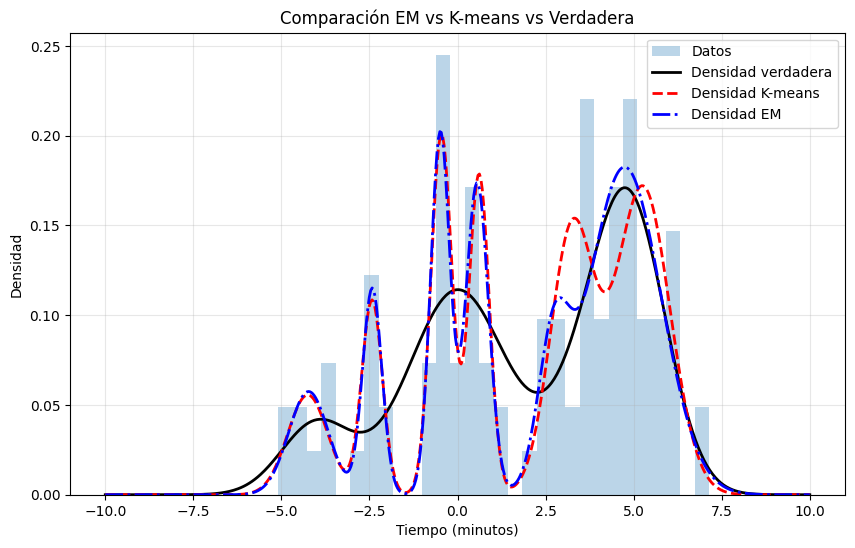

In [6]:
# Entrenamos EM inicializado con K-means
em = EM(n_components=6, max_iter=100, tol=1e-4)
em.fit(X, init_means=kmeans_means, init_variances=kmeans_variances, init_weights=kmeans_weights)

# Calculamos densidad de EM
em_density = densidad_mezclas(x_plot, em.weights_, em.means_, em.variances_)

# Graficamos comparación EM vs K-means vs verdadera
plt.figure(figsize=(10, 6))
plt.hist(X, bins=30, density=True, alpha=0.3, label='Datos')
plt.plot(x_plot, true_density, 'k-', linewidth=2, label='Densidad verdadera')
plt.plot(x_plot, kmeans_density, 'r--', linewidth=2, label='Densidad K-means')
plt.plot(x_plot, em_density, 'b-.', linewidth=2, label='Densidad EM')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Densidad')
plt.title('Comparación EM vs K-means vs Verdadera')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Este gráfico ilustra el incremento en la fidelidad del modelo que se obtiene al pasar de un enfoque geométrico (K-means) a un marco de inferencia probabilístico como el algoritmo de Expectation-Maximization (EM). Manteniendo como referencia la densidad verdadera (línea negra sólida) y la estimación inicial de K-means (línea roja discontinua), se introduce la densidad obtenida tras el ajuste con EM (línea azul punteada y discontinua).
La curva de EM se alinea de manera mucho más precisa con la distribución real en comparación con la de K-means. Este avance se debe a la naturaleza fundamental de EM, que, en lugar de realizar asignaciones "duras" y rígidas, emplea "asignaciones blandas" o responsabilidades probabilísticas. Esto significa que cada punto de dato contribuye a la estimación de los parámetros de múltiples componentes según su probabilidad de pertenencia, lo que permite al modelo capturar de forma más efectiva el solapamiento natural entre los grupos. El algoritmo refina iterativamente los parámetros iniciales (proporcionados por K-means) para maximizar la verosimilitud logarítmica de los datos. Como resultado, el modelo EM corrige las deficiencias más evidentes de K-means; por ejemplo, fusiona los dos picos espurios que K-means había creado alrededor de t=4 en un único modo que se asemeja mucho más al componente verdadero.


## Gaussian Variational Bayes:


Variational Bayes aproxima la verdadera distribución a posteriori $p(\theta, Z | X)$ (donde $Z$ son las variables latentes) con una distribución más simple $q(\theta, Z)$ que pertenece a una familia tratable. La idea central es encontrar la distribución $q$ dentro de esta familia que esté más cercana a la verdadera posteriori en el sentido de minimizar la divergencia de Kullback-Leibler:

$$\text{KL}(q \| p) = \int q(\theta, Z) \log \frac{q(\theta, Z)}{p(\theta, Z | X)} \, d\theta \, dZ.$$
Minimizar esta divergencia es equivalente a maximizar el Evidence Lower Bound (ELBO):

$$\mathcal{L}(q) = \int q(\theta, Z) \log \frac{p(X, Z, \theta)}{q(\theta, Z)} \, d\theta \, dZ.$$
El ELBO es una cota inferior de la log-evidencia $\log p(X)$ y se convierte en nuestra función objetivo.

Para hacer el problema tratable, asumimos una factorización mean-field:

$$q(\theta, Z) = q(Z) \prod_{\text{parámetros}} q(\text{parámetro})$$
Específicamente, para mezclas gaussianas con priors conjugados, asumimos

$$q(Z, \pi, \mu, \lambda) = q(Z) q(\pi) \prod_{k=1}^{K} q(\mu_k, \lambda_k)$$
donde $\lambda_k = 1/\sigma_k^2$ son las precisiones. Los priors conjugados que especificamos son: una Dirichlet para los pesos $\pi \sim \text{Dir}(\alpha_0)$ con $\alpha_0 = (1, 1, 1, 1, 1, 1)$, y para cada componente $k$, un prior Normal-Gamma sobre $(\mu_k, \lambda_k)$:

$$p(\mu_k, \lambda_k) = \mathcal{N}(\mu_k | m_0, (\delta_0 \lambda_k)^{-1}) \, \text{Gamma}(\lambda_k | \nu_0/2, \beta_0/2)$$
con hiperparámetros $m_0 = 0$, $\delta_0 = 0.05$, $\nu_0 = 0.05$, $\beta_0 = 0.05$.

Bajo la aproximación mean-field, las distribuciones variacionales óptimas tienen la forma de los priors conjugados pero con parámetros actualizados. Para las asignaciones latentes, obtenemos $q(z_i = k) = r_{ik}$, donde las responsabilidades se calculan como:
$$
\log r_{ik} \propto \mathbb{E}_q[\log \pi_k] + \frac{1}{2}\mathbb{E}_q[\log \lambda_k] - \frac{1}{2}\mathbb{E}_q[\lambda_k(x_i - \mu_k)^2].
$$
Las esperanzas se evalúan bajo las distribuciones variacionales actuales:
$$
\mathbb{E}_q[\log \pi_k] = \psi(\alpha_k) - \psi\left(\sum_j \alpha_j\right), $$
$$
\mathbb{E}_q[\log \lambda_k] = \psi(\nu_k/2) + \log(2/\beta_k), $$
$$\mathbb{E}_q[\lambda_k] = \nu_k/\beta_k, $$
$$\mathbb{E}_q[\lambda_k(x_i - \mu_k)^2] = \frac{\nu_k}{\beta_k} \cdot (x_i - m_k)^2 + \frac{1}{\delta_k},
$$
donde $\psi$ es la función digamma.

Para los parámetros de la mezcla, las distribuciones variacionales son:
$$
q(\pi) = \text{Dir}(\alpha), $$
$$q(\mu_k, \lambda_k) = \mathcal{N}(\mu_k | m_k, (\delta_k \lambda_k)^{-1}) \, \text{Gamma}(\lambda_k | \nu_k/2, \beta_k/2).
$$
Los parámetros variacionales se actualizan en el M-step como:
$$
\alpha_k = \alpha_{0k} + N_k, $$
$$\delta_k = \delta_0 + N_k, $$
$$m_k = \frac{\delta_0 m_0 + N_k \bar{x}_k}{\delta_k}, $$
$$\nu_k = \nu_0 + N_k, $$
$$\beta_k = \beta_0 + S_k + \frac{\delta_0 N_k}{\delta_k}(\bar{x}_k - m_0)^2,
$$
donde $N_k = \sum_i r_{ik}$, $\bar{x}_k = \frac{1}{N_k}\sum_i r_{ik} x_i$, y $S_k = \sum_i r_{ik}(x_i - \bar{x}_k)^2$.

El algoritmo VB alterna entre actualizar las responsabilidades (E-step variacional) y actualizar los parámetros variacionales (M-step variacional) hasta convergencia, que monitoreamos mediante el ELBO.  VB  permite selección automática de modelos: si especificamos más componentes de los necesarios con priors apropiados, los componentes superfluos reciben peso posterior cercano a cero ($\alpha_k \approx \alpha_{0k}$), efectivamente ``apagándose''. Esto ocurre porque el ELBO penaliza la complejidad del modelo, balanceando ajuste a los datos con parsimonia.

Para generar predicciones, VB ofrece dos alternativas. Primero, podemos muestrear parámetros de las distribuciones a posteriori $q(\pi)$ y $q(\mu_k, \lambda_k)$ y evaluar la densidad condicional $p(x | \pi, \mu, \lambda)$ para estos parámetros muestreados. Esto nos permite visualizar la incertidumbre sobre el modelo generado por la incertidumbre paramétrica. Segundo, podemos calcular la densidad predictiva integrando sobre la posteriori:
$$
p(x | X) = \int p(x | \theta) q(\theta) \, d\theta.
$$
En la práctica, aproximamos esta integral mediante Monte Carlo: muestreamos muchos conjuntos de parámetros de $q(\theta)$ y promediamos las densidades resultantes. Esta densidad predictiva incorpora completamente la incertidumbre bayesiana y es teóricamente superior para predicción que simplemente usar las medias posteriores de los parámetros.

La inicialización de VB también es importante, y utilizamos las probabilidades obtenidas del algoritmo EM como responsabilidades iniciales $r_{ik}^{(0)}$. Esto proporciona un punto de partida informado que acelera la convergencia. La condición de parada dual monitorea el cambio en el ELBO, deteniendo el algoritmo cuando $|\mathcal{L}^{(t)} - \mathcal{L}^{(t-1)}| < \epsilon$ o cuando se alcanza el máximo de iteraciones. El ELBO siempre aumenta (o permanece constante) en cada iteración, garantizando convergencia monotónica, aunque nuevamente solo a un máximo local.


In [7]:
class GaussianVariationalBayes:
    def __init__(self, n_components=6, max_iter=100, tol=1e-4, m=0, delta=0.05, nu=0.05, beta=0.05, alpha=None):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.m0 = m
        self.delta0 = delta
        self.nu0 = nu
        self.beta0 = beta
        self.alpha0 = np.ones(n_components) if alpha is None else np.array(alpha)


    def fit(self, X, init_proba=None):

        n_samples = X.shape[0]
        X_flat = X.flatten()  # Aplanamos los datos

        # Inicializamos parámetros variacionales
        self.m = np.random.randn(self.n_components) * 2  # Medias aleatorias
        self.delta = np.ones(self.n_components) * self.delta0  # Precisiones
        self.nu = np.ones(self.n_components) * self.nu0  # Grados de libertad
        self.beta = np.ones(self.n_components) * self.beta0  # Escalas
        self.alpha = self.alpha0.copy()  # Parámetros Dirichlet

        # Inicializamos responsabilidades
        r = init_proba.copy() if init_proba is not None else np.random.dirichlet(np.ones(self.n_components), n_samples)

        # Lower bound anterior para verificar convergencia
        prev_lower_bound = -np.inf

        # Iteramos hasta convergencia o máximo de iteraciones
        for iteration in range(self.max_iter):
            # E-step variacional: Actualizar responsabilidades
            log_rho = np.zeros((n_samples, self.n_components))

            for k in range(self.n_components):
                # E[log π_k]
                E_log_pi = digamma(self.alpha[k]) - digamma(np.sum(self.alpha))
                # E[log λ_k]
                E_log_lambda = digamma(0.5 * self.nu[k]) + np.log(2 / self.beta[k])
                # E[λ_k]
                E_lambda = self.nu[k] / self.beta[k]
                # E[(x - μ_k)^2 λ_k]
                E_quad = self.nu[k] / self.beta[k] * (X_flat - self.m[k])**2 + 1 / self.delta[k]

                # log ρ_nk (sin normalizar)
                log_rho[:, k] = E_log_pi + 0.5 * E_log_lambda - 0.5 * E_quad

            # Normalizamos usando log-sum-exp para estabilidad numérica
            log_rho_max = np.max(log_rho, axis=1, keepdims=True)
            rho = np.exp(log_rho - log_rho_max)
            r = rho / np.sum(rho, axis=1, keepdims=True)

            # M-step variacional: Actualizar parámetros
            N_k = np.sum(r, axis=0)  # Número efectivo de muestras por componente
            x_bar_k = np.sum(r * X_flat[:, np.newaxis], axis=0) / N_k  # Media ponderada

            for k in range(self.n_components):
                # Actualizamos α_k
                self.alpha[k] = self.alpha0[k] + N_k[k]

                # Actualizamos δ_k
                self.delta[k] = self.delta0 + N_k[k]

                # Actualizamos m_k
                self.m[k] = (self.delta0 * self.m0 + N_k[k] * x_bar_k[k]) / self.delta[k]

                # Actualizamos ν_k
                self.nu[k] = self.nu0 + N_k[k]

                # Calculamos S_k (suma ponderada de cuadrados)
                S_k = np.sum(r[:, k] * (X_flat - x_bar_k[k])**2)

                # Actualizamos β_k
                self.beta[k] = self.beta0 + S_k + \
                              (self.delta0 * N_k[k] / self.delta[k]) * (x_bar_k[k] - self.m0)**2

            # Calculamos lower bound (ELBO) para verificar convergencia
            lower_bound = 0
            # Contribución de los datos
            for k in range(self.n_components):
                E_log_pi = digamma(self.alpha[k]) - digamma(np.sum(self.alpha))
                E_log_lambda = digamma(0.5 * self.nu[k]) + np.log(2 / self.beta[k])
                E_lambda = self.nu[k] / self.beta[k]

                for i in range(n_samples):
                    E_quad = E_lambda * (X_flat[i] - self.m[k])**2 + 1 / self.delta[k]
                    lower_bound += r[i, k] * (E_log_pi + 0.5 * E_log_lambda - 0.5 * E_quad - 0.5 * np.log(2 * np.pi))

            # Verificamos convergencia
            if np.abs(lower_bound - prev_lower_bound) < self.tol:
                break
            prev_lower_bound = lower_bound

        return self

    def predict_proba(self, X):
        n_samples = X.shape[0]
        X_flat = X.flatten()
        proba = np.zeros((n_samples, self.n_components))

        # Usamos las medias esperadas de los parámetros
        for k in range(self.n_components):
            E_pi = self.alpha[k] / np.sum(self.alpha)
            E_lambda = self.nu[k] / self.beta[k]
            proba[:, k] = E_pi * np.sqrt(E_lambda / (2 * np.pi)) * \
                         np.exp(-0.5 * E_lambda * (X_flat - self.m[k])**2)

        # Normalizamos
        proba_sum = np.sum(proba, axis=1, keepdims=True)
        proba_sum[proba_sum == 0] = 1e-10
        proba = proba / proba_sum

        return proba

    def predict(self, X):

        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

    def sample_parameters(self, n_samples=1):

        samples = []

        for _ in range(n_samples):
            # Muestreamos pesos de Dirichlet
            weights = np.random.dirichlet(self.alpha)

            means = np.zeros(self.n_components)
            precisions = np.zeros(self.n_components)

            for k in range(self.n_components):
                # Muestreamos precisión de Gamma
                precisions[k] = np.random.gamma(0.5 * self.nu[k], 2 / self.beta[k])
                # Muestreamos media de Normal
                means[k] = np.random.normal(self.m[k], 1 / np.sqrt(self.delta[k] * precisions[k]))

            samples.append({
                'weights': weights,
                'means': means,
                'precisions': precisions,
                'variances': 1 / precisions  # Convertimos a varianzas
            })

        return samples


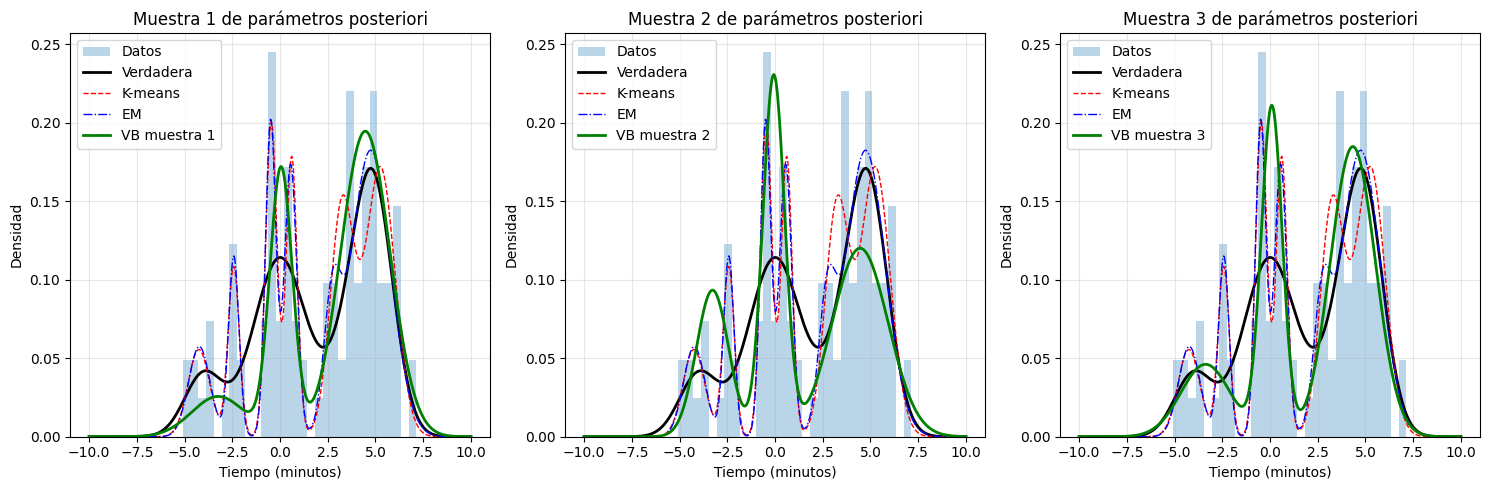

In [8]:
# Entrenamos Variational Bayes inicializado con EM
vb = GaussianVariationalBayes(n_components=6, max_iter=100, tol=1e-4,
                              m=0, delta=0.05, nu=0.05, beta=0.05,
                              alpha=[1, 1, 1, 1, 1, 1])
# Obtenemos probabilidades del EM para inicializar
em_proba = em.predict_proba(X)
vb.fit(X, init_proba=em_proba)

# Generamos 3 muestras de parámetros de la posteriori
posterior_samples = vb.sample_parameters(n_samples=3)

# Graficamos densidades para cada muestra de parámetros
plt.figure(figsize=(15, 5))
for i, params in enumerate(posterior_samples):
    plt.subplot(1, 3, i+1)
    # Calculamos densidad con los parámetros muestreados
    sampled_density = densidad_mezclas(x_plot, params['weights'],
                                     params['means'], params['variances'])
    plt.hist(X, bins=30, density=True, alpha=0.3, label='Datos')
    plt.plot(x_plot, true_density, 'k-', linewidth=2, label='Verdadera')
    plt.plot(x_plot, kmeans_density, 'r--', linewidth=1, label='K-means')
    plt.plot(x_plot, em_density, 'b-.', linewidth=1, label='EM')
    plt.plot(x_plot, sampled_density, 'g-', linewidth=2, label=f'VB muestra {i+1}')
    plt.xlabel('Tiempo (minutos)')
    plt.ylabel('Densidad')
    plt.title(f'Muestra {i+1} de parámetros posteriori')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



 Cada subgráfico muestra una realización diferente de parámetros (pesos, medias y varianzas) muestreados de las distribuciones a posteriori aproximadas por Variational Bayes. El histograma y las densidades verdadera (negra), K-means (roja discontinua) y EM (azul punteada-discontinua) se mantienen constantes en los tres paneles como referencia, pero la curva verde sólida cambia entre subgráficos, representando la densidad de la mezcla evaluada con diferentes conjuntos de parámetros muestreados.
  Esta variabilidad entre las tres muestras visualiza directamente la incertidumbre sobre los parámetros del modelo: si estuviéramos completamente seguros de los parámetros, las tres curvas verdes serían idénticas, pero la variación observada refleja que múltiples configuraciones paramétricas son plausibles dado los datos observados.
   Las diferencias entre las tres muestras ilustran las regiones del espacio de parámetros donde el modelo tiene mayor incertidumbre, típicamente donde los datos son más escasos o los componentes se solapan.


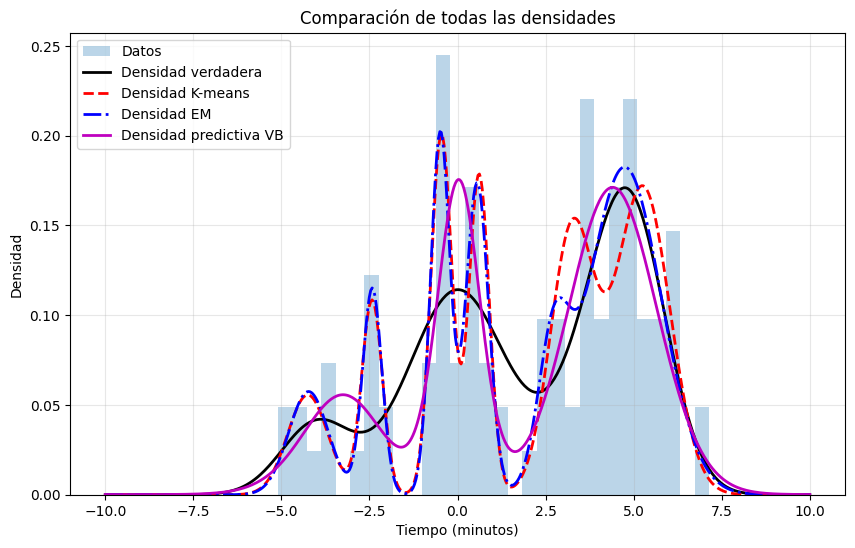

In [9]:
# Calculamos la densidad predictiva (promediando sobre la posteriori)
# Para esto generamos muchas muestras y promediamos
n_pred_samples = 1000
predictive_density = np.zeros_like(x_plot)

for _ in range(n_pred_samples):
    params = vb.sample_parameters(n_samples=1)[0]
    predictive_density += densidad_mezclas(x_plot, params['weights'],
                                         params['means'], params['variances'])

predictive_density /= n_pred_samples  # Promediamos

# Graficamos la densidad predictiva
plt.figure(figsize=(10, 6))
plt.hist(X, bins=30, density=True, alpha=0.3, label='Datos')
plt.plot(x_plot, true_density, 'k-', linewidth=2, label='Densidad verdadera')
plt.plot(x_plot, kmeans_density, 'r--', linewidth=2, label='Densidad K-means')
plt.plot(x_plot, em_density, 'b-.', linewidth=2, label='Densidad EM')
plt.plot(x_plot, predictive_density, 'm-', linewidth=2, label='Densidad predictiva VB')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Densidad')
plt.title('Comparación de todas las densidades')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El presente gráfico sintetiza la evaluación comparativa de todos los enfoques metodológicos aplicados, superponiendo las densidades estimadas por K-means (roja), EM (azul) y la densidad verdadera (negra), e introduce el resultado final del modelo bayesiano: la densidad predictiva (curva magenta sólida). Esta densidad no se deriva de una única estimación puntual de parámetros, como en el caso de EM, sino que se obtiene al marginar (integrar) la incertidumbre sobre los parámetros del modelo, lo que resulta en una predicción única y robusta para un nuevo punto de dato. El efecto de esta marginación de la incertidumbre paramétrica es una curva que, por lo general, es más suave y robusta que las estimaciones puntuales. Evita el sobreajuste al que son propensos los modelos de máxima verosimilitud (EM), como se observa en la menor agudeza de sus picos en comparación con la curva azul, logrando un mejor equilibrio que se aproxima a la forma de la densidad verdadera.